## ESA SST CCI

This notebook shows how to open data cubes from the ESA Open Data Portal for a given time range and region:

Download the respective subset nc file from: https://data.marine.copernicus.eu/product/SST_GLO_SST_L4_REP_OBSERVATIONS_010_024/download?dataset=C3S-GLO-SST-L4-REP-OBS-SST_202506

We start with necessary imports.

In [12]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

In [71]:
# import xarray as xr
# ds = xr.open_dataset('C3S-GLO-SST-L4-REP-OBS-SST_multi-vars_75.63W_10.33N_1982-01-01-2016-01-01.nc') # one pixel
ds = xr.open_dataset('C3S-GLO-SST-L4-REP-OBS-SST_1764346172284.nc') # several pixels
print(ds)

<xarray.Dataset> Size: 695kB
Dimensions:                (time: 12419, latitude: 1, longitude: 1)
Coordinates:
  * time                   (time) datetime64[ns] 99kB 1982-01-01 ... 2016-01-01
  * latitude               (latitude) float32 4B 10.33
  * longitude              (longitude) float32 4B -75.63
Data variables:
    analysed_sst           (time, latitude, longitude) float64 99kB ...
    analysed_st            (time, latitude, longitude) float64 99kB ...
    analysis_error_sst     (time, latitude, longitude) float64 99kB ...
    analysis_error_st      (time, latitude, longitude) float64 99kB ...
    mask                   (time, latitude, longitude) float32 50kB ...
    sea_ice_fraction       (time, latitude, longitude) float64 99kB ...
    sea_ice_fraction_flag  (time, latitude, longitude) float32 50kB ...
Attributes:
    Conventions:               CF-1.4, Unidata Observation Dataset v1.0
    title:                     Global Sea and Ice Surface Temperature, L4, 5k...
    source:  

In [50]:
print("\nData variables:")
print(list(ds.data_vars))                      # shows only the actual variables (not coords)


Data variables:
['analysed_sst', 'analysed_st', 'analysis_error_sst', 'analysis_error_st', 'mask', 'sea_ice_fraction', 'sea_ice_fraction_flag']


### Check values:

In [51]:
# 2. Look at the first variable that contains SST (99% of cases it’s one of these)
print("\nFirst few values of the main variable:")
print(ds[list(ds.data_vars)[0]].isel(time=2).values[0:50, 0:50])


First few values of the main variable:
[[301.28999327]]


### Check coordinates available:

In [54]:
# Print the latitude and longitude coordinates nicely
print("=== LATITUDES ===")
print(f"Number of latitude points : {len(ds.latitude)}")
print(f"From {ds.latitude.values.min():.4f}° to {ds.latitude.values.max():.4f}°")
# print(f"Step size                 : {float(ds.latitude[1] - ds.latitude[0]):.4f}°")
# print("First 10 values :", ds.latitude.values[:10])
# print("Last 10 values  :", ds.latitude.values[-10:])

print("\n=== LONGITUDES ===")
print(f"Number of longitude points: {len(ds.longitude)}")
print(f"From {ds.longitude.values.min():.4f}° to {ds.longitude.values.max():.4f}°")
# Handle the 0–360 vs -180–180 convention
# if ds.longitude.max() > 180:
#     print("(longitudes are 0°–360°)")
# else:
#     print("(longitudes are -180°–180°)")
# print(f"Step size                 : {float(ds.longitude[1] - ds.longitude[0]):.4f}°")
# print("First 10 values :", ds.longitude.values[:10])
# print("Last 10 values  :", ds.longitude.values[-10:])

# Optional: see the exact grid shape
print(f"\nGrid shape (time × lat × lon): {ds['analysed_sst'].shape}")   # or whatever your SST variable is called

=== LATITUDES ===
Number of latitude points : 1
From 10.3250° to 10.3250°

=== LONGITUDES ===
Number of longitude points: 1
From -75.6250° to -75.6250°

Grid shape (time × lat × lon): (12419, 1, 1)


### Check projection:

In [48]:
# 1. Look for a "grid_mapping" attribute (this is the official CF-convention way)
for var in ds.data_vars:
    if hasattr(ds[var], 'grid_mapping'):
        mapping_name = ds[var].grid_mapping
        print(f"\n→ Variable '{var}' uses grid_mapping: {mapping_name}")
        if mapping_name in ds:
            print("   Grid mapping details:")
            print(ds[mapping_name])

# 2. Simple heuristic that works 99.9% of the time for ESA SST CCI / Copernicus
if 'latitude' in ds.coords and 'longitude' in ds.coords:
    if ds.latitude.dims == ('latitude',) and ds.longitude.dims == ('longitude',):
        print("\n→ This file is in a regular latitude/longitude grid (PlateCarree / EPSG:4326)")
        print("   → You can safely plot with projection=ccrs.PlateCarree()")
    else:
        print("\n→ 2D lat/lon arrays → curvilinear grid (rare in L4 SST products)")

# 3. Bonus: print CRS string if it exists (some files have it directly)
if 'crs' in ds:
    print("\nCRS variable found:")
    print(ds.crs)


→ This file is in a regular latitude/longitude grid (PlateCarree / EPSG:4326)
   → You can safely plot with projection=ccrs.PlateCarree()


In [62]:
# Pick the first time step and the correct SST variable
# (adjust the variable name if yours is different)
sst = ds['analysed_sst'].isel(time=100) - 273.15   # convert Kelvin → °C
# Remove fill values (important!)
sst = sst.where(sst < 1000)

List available stores:

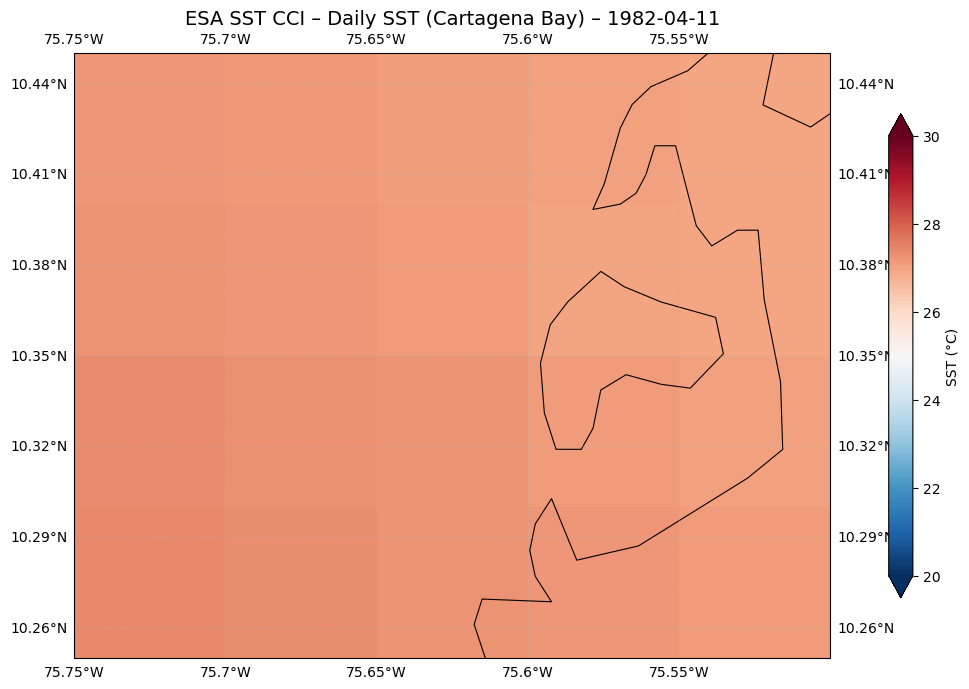

In [64]:
# Quick beautiful plot
fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
sst.plot(ax=ax,
         transform=ccrs.PlateCarree(),
         cmap='RdBu_r',
         cbar_kwargs={'label': 'SST (°C)', 'shrink': 0.8},
         vmin=20, vmax=30,          # adjust if you’re in polar regions
         extend='both')

ax.coastlines(resolution='10m', linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')

time_str = str(ds.time.isel(time=100).dt.strftime('%Y-%m-%d').values)
plt.title(f'ESA SST CCI – Daily SST (Cartagena Bay) – {time_str}', fontsize=14)
plt.tight_layout()
plt.show()

### Monthly means

In [77]:
# Replace 'analysed_sst' with your actual variable name if different
var = 'analysed_sst'          # ← common names: analysed_sst, sea_surface_temperature, sst
sst_data = ds[var] - 273.15        # convert Kelvin → °C once and for all

# Remove fill values (important!)
sst_data = sst_data.where(sst_data < 1000)

print(f"Original daily data: {sst_data.time.size} days")

Original daily data: 12419 days


In [78]:
# This gives you one value per month (408 months from Jan 1982 → Dec 2015)
monthly = sst_data.resample(time='1MS').mean(dim='time')   # '1MS' = month start

print(f"→ Monthly means created: {monthly.time.size} months")

# Save to a new NetCDF file (highly recommended!)
monthly.to_netcdf("monthly_mean_SST_1982_2015.nc")
print("Saved as monthly_mean_SST_1982_2015.nc")

→ Monthly means created: 409 months
Saved as monthly_mean_SST_1982_2015.nc


In [83]:
lon_target = -75.625                         # your desired longitude
lat_target =  10.325                         # your desired latitude

# Extract the nearest grid point (most accurate)
point_ts_daily = sst_data.sel(longitude=lon_target, latitude=lat_target, method='nearest')

# Convert daily → monthly means
point_ts_monthly = point_ts_daily.resample(time='1MS').std()

# Create a nice pandas DataFrame
df = point_ts_monthly.to_dataframe()

# Rename column to something readable
df = df.rename(columns={sst_var: 'SST_monthly_C'})

# Optional: add the exact coordinates that were actually used
actual_lon = point_ts_monthly.latitude.values
actual_lat = point_ts_monthly.latitude.values
df['longitude'] = actual_lon
df['latitude']  = actual_lat

# Reset index to have clean "time" column
df = df.reset_index()[['time', 'latitude', 'longitude', 'SST_monthly_C']]

# Round for readability
df['SST_monthly_C'] = df['SST_monthly_C'].round(3)

# Save to CSV
df.to_csv(f"SST_monthly_{lat_target}N_{lon_target}E_1982_2015.csv", 
          index=False, float_format='%.3f')

print("Done!")
print(f"→ Saved {len(df)} monthly values")
print(f"→ Exact location used: {actual_lat}°N, {actual_lon}°E")
print(df.head(12))

Done!
→ Saved 409 monthly values
→ Exact location used: 10.325002670288086°N, 10.325002670288086°E
         time   latitude  longitude  SST_monthly_C
0  1982-01-01  10.325003  10.325003          0.642
1  1982-02-01  10.325003  10.325003          0.469
2  1982-03-01  10.325003  10.325003          0.584
3  1982-04-01  10.325003  10.325003          0.816
4  1982-05-01  10.325003  10.325003          0.183
5  1982-06-01  10.325003  10.325003          0.519
6  1982-07-01  10.325003  10.325003          0.449
7  1982-08-01  10.325003  10.325003          0.351
8  1982-09-01  10.325003  10.325003          0.540
9  1982-10-01  10.325003  10.325003          0.487
10 1982-11-01  10.325003  10.325003          0.813
11 1982-12-01  10.325003  10.325003          0.528
